<a href="https://colab.research.google.com/github/mathy-analyst/training1/blob/tests_colab/expos%C3%A9_histogramme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse Approfondie de la Visualisation par Histogramme : Au-delà des Bases

**Objectif de l'exposé :** Pour un data analyst, l'histogramme est un outil fondamental, souvent l'une des premières visualisations que nous créons. Cependant, sa simplicité apparente peut être trompeuse. Le choix des paramètres, l'interprétation des formes et l'intégration dans un flux d'analyse plus large sont des compétences qui distinguent une analyse basique d'une analyse experte.

Cet exposé ne vise pas à vous apprendre *comment* tracer un histogramme, mais plutôt *pourquoi* et *quand* l'utiliser, comment en extraire un maximum d'informations, et quand il est plus judicieux de se tourner vers d'autres visualisations. Nous répondrons à des questions critiques :
*   **Pourquoi un histogramme est-il le choix approprié pour une variable donnée ?**
*   **Comment nos choix (ex: le nombre de "bins") influencent-ils l'histoire que racontent les données ?**
*   **Comment utiliser l'histogramme non seulement pour décrire, mais aussi pour transformer et préparer nos données ?**

**Le jeu de données :** Nous utiliserons le jeu de données "California Housing". Il est idéal car il contient des variables aux distributions variées (normales, skewées, multimodales), ce qui nous permettra d'explorer les subtilités de l'histogramme.

**Lien vers les données :** [https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv](https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv)

In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour de meilleurs visuels
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Chargement du jeu de données depuis l'URL fournie
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
housing_df = pd.read_csv(url)

# Aperçu des données
print("Aperçu des 5 premières lignes :")
display(housing_df.head())

print("\nInformations sur les types de données et les valeurs manquantes :")
housing_df.info()

Aperçu des 5 premières lignes :


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Informations sur les types de données et les valeurs manquantes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Partie 1 : Le Cas d'Usage Classique - Comprendre la Distribution d'une Variable Cible

La première question que nous nous posons souvent est : "À quoi ressemble notre variable cible ?". Ici, nous nous intéressons à la valeur médiane des maisons (`median_house_value`).

**Justification du choix de l'histogramme :**
Pour une variable numérique continue comme `median_house_value`, l'histogramme est l'outil le plus direct pour répondre à cette question. Il nous permet de visualiser instantanément :
1.  **La tendance centrale :** Où se situent la plupart des données ?
2.  **La dispersion :** Les valeurs sont-elles concentrées ou étalées ?
3.  **L'asymétrie (Skewness) :** La distribution est-elle penchée à gauche ou à droite ?
4.  **Les valeurs aberrantes (Outliers) :** Y a-t-il des valeurs isolées loin du reste de la distribution ?
5.  **Les modes :** La distribution a-t-elle un ou plusieurs pics ?

Un simple `df.describe()` nous donne des chiffres, mais l'histogramme nous donne une *forme*, une intuition bien plus puissante.

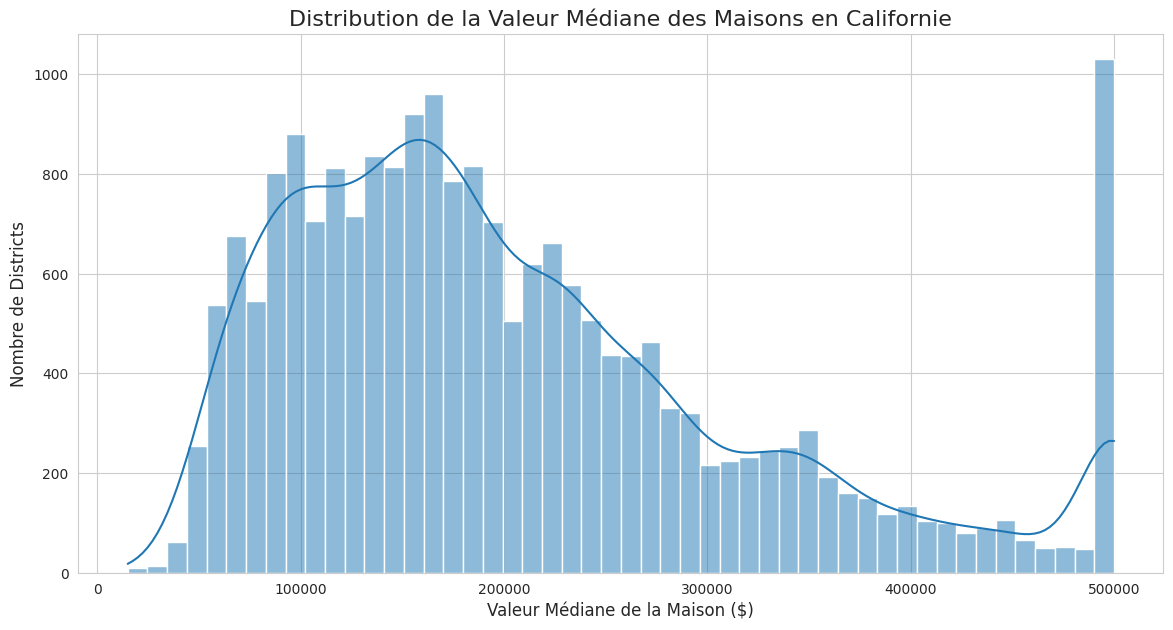


Observations clés de l'histogramme :
1. Distribution fortement asymétrique à droite (right-skewed).
2. Un pic très important semble se situer à la valeur maximale de 500001. Cela suggère que les données ont été "plafonnées" (capped) à cette valeur.
3. La plupart des valeurs se concentrent entre 100 000$ et 250 000$.



In [2]:
# Visualisation de la distribution de la valeur médiane des maisons
plt.figure(figsize=(14, 7))
sns.histplot(housing_df['median_house_value'], kde=True, bins=50)
plt.title('Distribution de la Valeur Médiane des Maisons en Californie', fontsize=16)
plt.xlabel('Valeur Médiane de la Maison ($)', fontsize=12)
plt.ylabel('Nombre de Districts', fontsize=12)
plt.show()

# Analyse des observations
print("""
Observations clés de l'histogramme :
1. Distribution fortement asymétrique à droite (right-skewed).
2. Un pic très important semble se situer à la valeur maximale de 500001. Cela suggère que les données ont été "plafonnées" (capped) à cette valeur.
3. La plupart des valeurs se concentrent entre 100 000$ et 250 000$.
""")

## Partie 2 : Le Dilemme du Nombre de Bins - L'Art de Révéler ou de Masquer l'Information

Le choix du nombre de "bins" (ou barres) est l'aspect le plus critique de la création d'un histogramme. C'est un compromis entre le **biais** (trop peu de bins, qui masque la structure réelle) et la **variance** (trop de bins, qui crée un graphique bruité et difficile à interpréter).

**Pourquoi est-ce crucial pour un analyste avancé ?**
Un mauvais choix de bins peut vous faire tirer de fausses conclusions. Trop peu de bins pourrait vous faire croire à une distribution unimodale alors qu'elle est bimodale. Trop de bins pourrait vous faire interpréter du bruit aléatoire comme un pic significatif.

Nous allons explorer l'impact de ce choix sur la variable `median_income`.

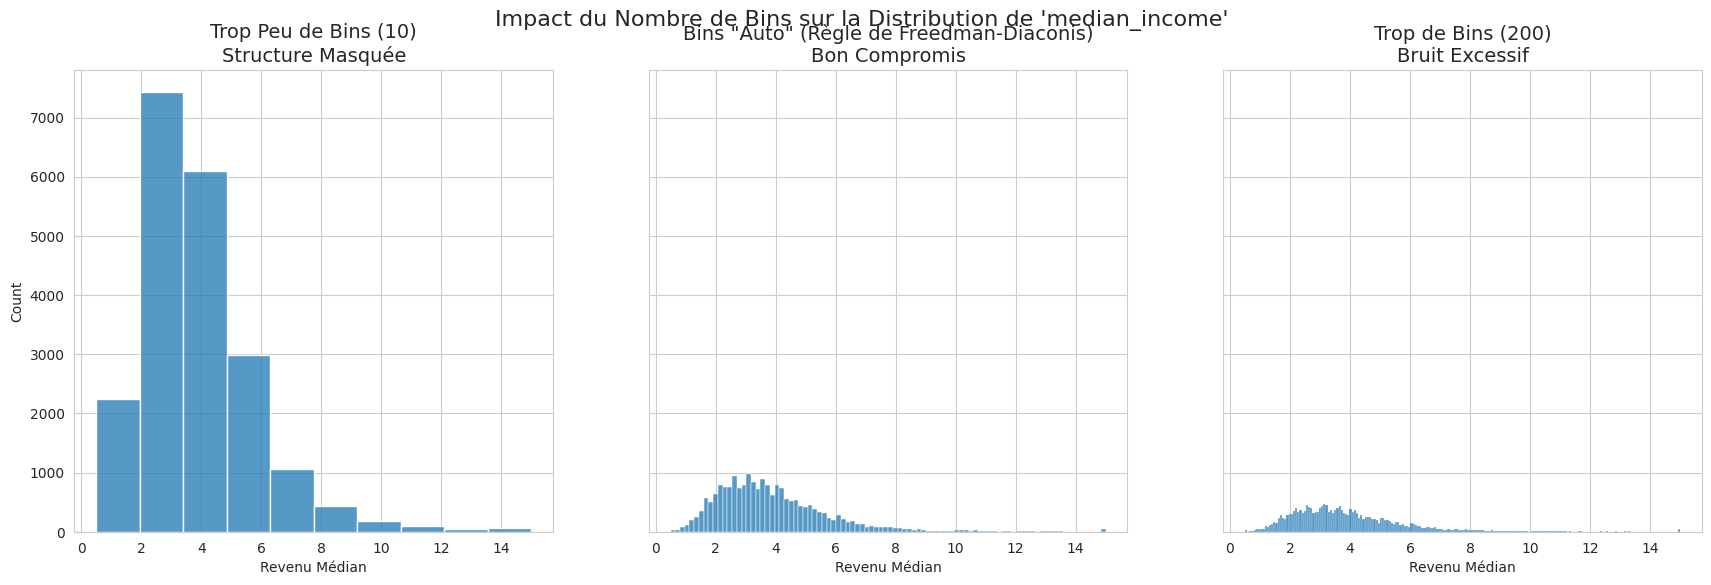


Conclusion sur le choix des bins :
- Le graphique du milieu, utilisant la règle 'auto' de Seaborn (souvent basée sur la règle de Freedman-Diaconis), offre la vision la plus équilibrée.
- Il révèle plusieurs pics, suggérant des groupes socio-économiques distincts, une information cruciale qui serait perdue avec seulement 10 bins.
- Le graphique avec 200 bins est trop "bruyant". Les pics nombreux et fins sont probablement dus à des fluctuations aléatoires plutôt qu'à de véritables groupes dans la population.



In [4]:
variable_to_explore = 'median_income'

fig, axes = plt.subplots(1, 3, figsize=(21, 6), sharey=True)
fig.suptitle(f"Impact du Nombre de Bins sur la Distribution de '{variable_to_explore}'", fontsize=16)

# Trop peu de bins (biais élevé)
sns.histplot(housing_df[variable_to_explore], bins=10, ax=axes[0], kde=False)
axes[0].set_title('Trop Peu de Bins (10)\nStructure Masquée', fontsize=14)
axes[0].set_xlabel('Revenu Médian')

# Nombre de bins par défaut (souvent un bon compromis)
sns.histplot(housing_df[variable_to_explore], bins='auto', ax=axes[1], kde=False)
axes[1].set_title('Bins "Auto" (Règle de Freedman-Diaconis)\nBon Compromis', fontsize=14)
axes[1].set_xlabel('Revenu Médian')

# Trop de bins (variance élevée)
sns.histplot(housing_df[variable_to_explore], bins=200, ax=axes[2], kde=False)
axes[2].set_title('Trop de Bins (200)\nBruit Excessif', fontsize=14)
axes[2].set_xlabel('Revenu Médian')

plt.show()

print("""
Conclusion sur le choix des bins :
- Le graphique du milieu, utilisant la règle 'auto' de Seaborn (souvent basée sur la règle de Freedman-Diaconis), offre la vision la plus équilibrée.
- Il révèle plusieurs pics, suggérant des groupes socio-économiques distincts, une information cruciale qui serait perdue avec seulement 10 bins.
- Le graphique avec 200 bins est trop "bruyant". Les pics nombreux et fins sont probablement dus à des fluctuations aléatoires plutôt qu'à de véritables groupes dans la population.
""")

## Partie 3 : Comparer les Distributions - L'Histogramme comme Outil d'Analyse Comparative

L'histogramme devient encore plus puissant lorsqu'on l'utilise pour comparer des distributions entre différents groupes. La question ici est : **La distribution des prix des maisons varie-t-elle en fonction de leur proximité à l'océan ?**

**Justification du choix de l'histogramme superposé (`hue`) :**
Nous pourrions utiliser des box plots, mais un histogramme superposé nous donne une bien meilleure idée de la *forme* complète de la distribution pour chaque catégorie. Il nous permet de voir non seulement les différences de médiane ou de dispersion, mais aussi les différences de modalité (nombre de pics) et d'asymétrie.

**Est-ce l'outil le plus approprié ?**
- **Oui,** pour une analyse détaillée de la forme des distributions.
- **Non,** si l'objectif est uniquement de comparer des statistiques résumées (médiane, quartiles). Dans ce cas, un box plot serait plus lisible et moins sujet au sur-plotting (superposition des barres).

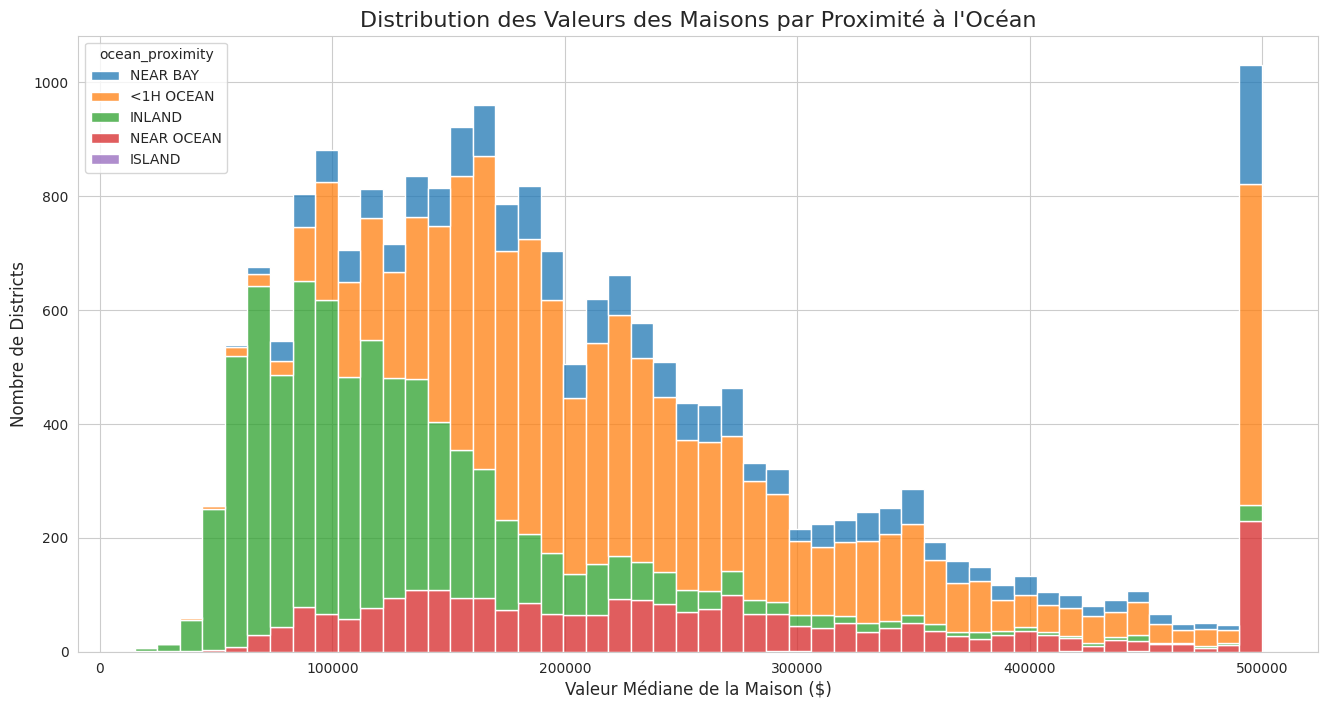


Analyse de la visualisation :
- 'INLAND' (à l'intérieur des terres) a une distribution des prix nettement plus basse et plus concentrée.
- 'NEAR OCEAN' et 'NEAR BAY' ont des distributions similaires, avec des prix plus élevés et plus étalés.
- 'ISLAND' a très peu d'observations, ce qui rend sa distribution difficile à interpréter.
- Le "plafonnement" à 500 000$ est particulièrement visible pour les catégories 'NEAR BAY' et 'NEAR OCEAN', ce qui indique que les maisons de luxe sont sur-représentées dans cette valeur maximale.

Cette visualisation est extrêmement riche. Elle nous montre que la localisation est un facteur prédictif majeur, et ce, de manière beaucoup plus nuancée qu'un simple graphique en barres des moyennes.



In [5]:
# Utilisation de seaborn pour comparer les distributions
plt.figure(figsize=(16, 8))
sns.histplot(
    data=housing_df,
    x='median_house_value',
    hue='ocean_proximity',
    multiple='stack', # Essayez aussi 'layer' ou 'dodge'
    bins=50,
    kde=False
)
plt.title('Distribution des Valeurs des Maisons par Proximité à l\'Océan', fontsize=16)
plt.xlabel('Valeur Médiane de la Maison ($)', fontsize=12)
plt.ylabel('Nombre de Districts', fontsize=12)
plt.show()

print("""
Analyse de la visualisation :
- 'INLAND' (à l'intérieur des terres) a une distribution des prix nettement plus basse et plus concentrée.
- 'NEAR OCEAN' et 'NEAR BAY' ont des distributions similaires, avec des prix plus élevés et plus étalés.
- 'ISLAND' a très peu d'observations, ce qui rend sa distribution difficile à interpréter.
- Le "plafonnement" à 500 000$ est particulièrement visible pour les catégories 'NEAR BAY' et 'NEAR OCEAN', ce qui indique que les maisons de luxe sont sur-représentées dans cette valeur maximale.

Cette visualisation est extrêmement riche. Elle nous montre que la localisation est un facteur prédictif majeur, et ce, de manière beaucoup plus nuancée qu'un simple graphique en barres des moyennes.
""")

Cellule 9 : Partie 4 - L'Histogramme pour le Feature Engineering (Markdown)

## Partie 4 : L'Histogramme comme Outil de Prétraitement et de Feature Engineering

Une visualisation n'est pas seulement descriptive ; elle est prescriptive. Elle nous indique les actions à entreprendre sur nos données. L'histogramme de `median_house_value` nous a clairement montré deux problèmes :
1.  **Asymétrie à droite :** La plupart des modèles de machine learning (particulièrement les modèles linéaires) fonctionnent mieux avec des distributions proches de la normale.
2.  **Plafonnement (Capping) :** La valeur de 500001 est artificielle et peut biaiser notre modèle.

**Justification de l'utilisation de l'histogramme pour guider la transformation :**
Avant d'appliquer une transformation (comme le logarithme), nous devons la justifier. L'histogramme "avant" et "après" est la preuve visuelle la plus convaincante que notre transformation a eu l'effet désiré : réduire l'asymétrie et rendre la distribution plus "gaussienne".

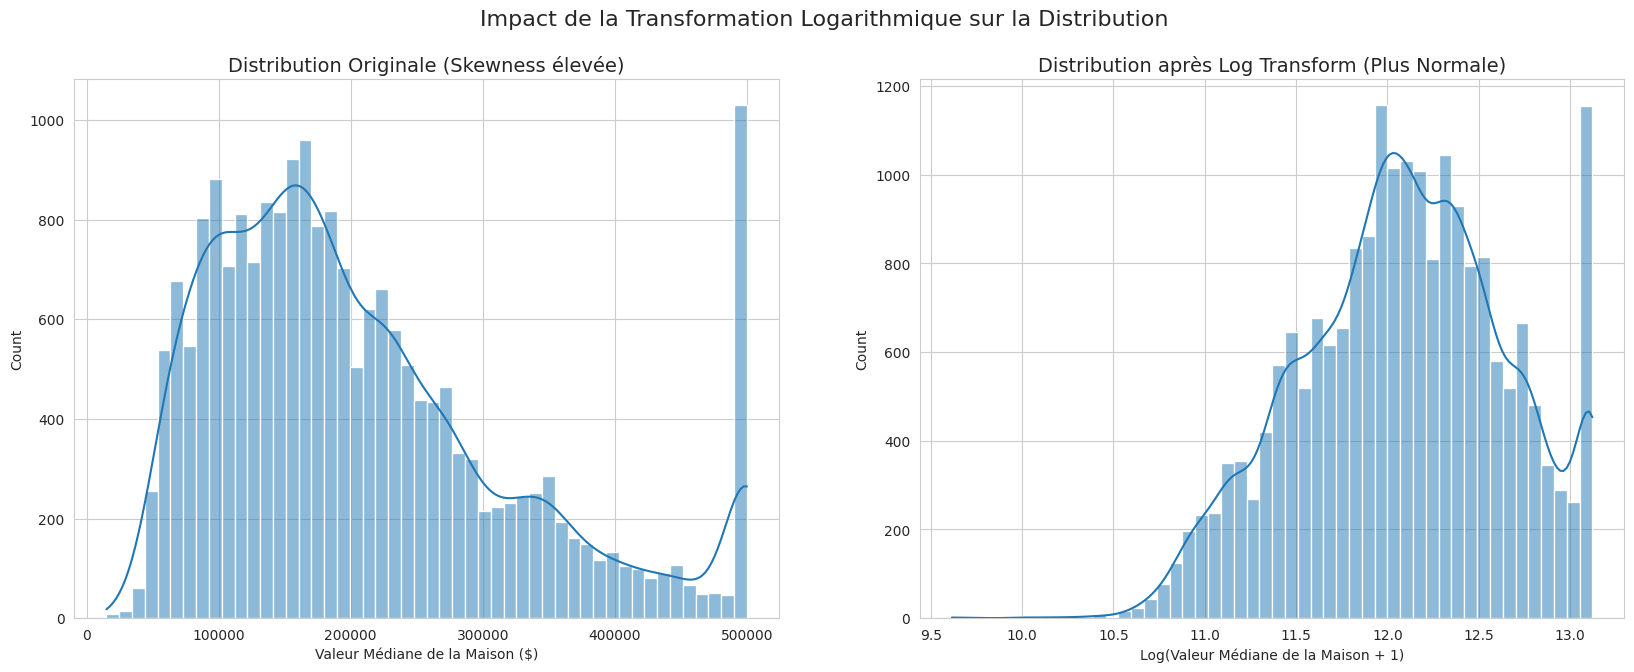


Conclusion de la transformation :
- La transformation logarithmique a considérablement réduit l'asymétrie.
- La distribution est maintenant beaucoup plus centrée et symétrique, ressemblant à une distribution normale.
- Le pic de valeurs plafonnées est toujours présent, mais son impact relatif sur la distribution globale est réduit.
- Pour un modèle de régression linéaire, `median_house_value_log` serait une bien meilleure cible que `median_house_value`.



In [6]:
# Création d'une copie pour ne pas altérer le DataFrame original
housing_transformed = housing_df.copy()

# 1. Gérer le plafonnement : Option 1 - Supprimer les valeurs plafonnées
# Option 2 - Les traiter comme une catégorie à part (plus avancé)
# Ici, nous allons simplement les garder en tête et voir l'effet de la transformation.

# 2. Appliquer une transformation logarithmique pour réduire l'asymétrie
# On ajoute 1 pour éviter log(0), bien que ce ne soit pas un problème ici.
housing_transformed['median_house_value_log'] = np.log1p(housing_transformed['median_house_value'])

# Visualisation comparée
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("Impact de la Transformation Logarithmique sur la Distribution", fontsize=16)

# Histogramme original
sns.histplot(housing_transformed['median_house_value'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution Originale (Skewness élevée)', fontsize=14)
axes[0].set_xlabel('Valeur Médiane de la Maison ($)')

# Histogramme après transformation log
sns.histplot(housing_transformed['median_house_value_log'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution après Log Transform (Plus Normale)', fontsize=14)
axes[1].set_xlabel('Log(Valeur Médiane de la Maison + 1)')

plt.show()

print("""
Conclusion de la transformation :
- La transformation logarithmique a considérablement réduit l'asymétrie.
- La distribution est maintenant beaucoup plus centrée et symétrique, ressemblant à une distribution normale.
- Le pic de valeurs plafonnées est toujours présent, mais son impact relatif sur la distribution globale est réduit.
- Pour un modèle de régression linéaire, `median_house_value_log` serait une bien meilleure cible que `median_house_value`.
""")

## Conclusion : L'Histogramme est une Conversation, pas une Simple Image

Nous avons vu que l'histogramme est bien plus qu'un simple graphique de barres. C'est un outil d'investigation interactif qui nous pousse à nous poser les bonnes questions.

**Résumé des justifications :**
1.  **Pour explorer une variable unique ?** Oui, c'est le meilleur point de départ pour comprendre la forme, la tendance centrale et les anomalies.
2.  **Pour comparer des groupes ?** C'est un excellent choix pour une analyse comparative détaillée de la forme des distributions, mais attention au sur-plotting. Un box plot ou un violin plot peut être un complément ou une alternative plus lisible pour les statistiques résumées.
3.  **Pour guider le prétraitement ?** Absolument. C'est l'un de ses usages les plus puissants pour un data analyst, car il connecte directement la visualisation à l'action (transformation, nettoyage).

**Quand l'histogramme n'est-il pas le plus approprié ?**
- **Pour comparer les distributions de plus de 3-4 groupes :** Il devient illisible. Préférez des box plots ou des violin plots.
- **Pour des données catégorielles :** Utilisez un diagramme en barres (bar chart).
- **Pour visualiser la relation entre deux variables numériques :** Utilisez un nuage de points (scatter plot).

L'outil le plus approprié est toujours celui qui répond le plus clairement à la question que vous vous posez, tout en minimisant les risques de mauvaise interprétation. La maîtrise de l'histogramme, y compris de ses limites, est une étape essentielle vers une analyse de données plus rigoureuse et plus perspicace.

## Quand l'Histogramme n'est pas l'Outil le Plus Approprié : Alternatives et Justifications

L'histogramme est roi pour l'analyse univariée (une seule variable numérique). Cependant, l'essentiel de l'analyse de données consiste à trouver des relations et des comparaisons. Forcer l'utilisation d'un histogramme dans ces contextes non seulement obscurcit l'information, mais peut aussi mener à des conclusions erronées.

Nous allons maintenant explorer trois scénarios clés où d'autres visualisations sont nettement supérieures, en montrant d'abord l'approche inefficace (avec l'histogramme) puis l'approche recommandée.

### Cas 1 : Comparer les Distributions de Plus de 3-4 Groupes

**La Question :** Comment la distribution de l'âge médian des maisons (`housing_median_age`) varie-t-elle selon la proximité à l'océan (`ocean_proximity`) ?

**Pourquoi l'histogramme est un mauvais choix :**
Lorsque l'on utilise `hue` pour superposer plus de 3 ou 4 distributions, l'histogramme devient rapidement illisible. Les barres se superposent (phénomène de *overplotting*), les couleurs se mélangent, et il devient impossible de distinguer la forme et la position de chaque distribution individuelle. On perd tout le pouvoir de comparaison.

Cas 1 - La Mauvaise Approche (Histogramme)

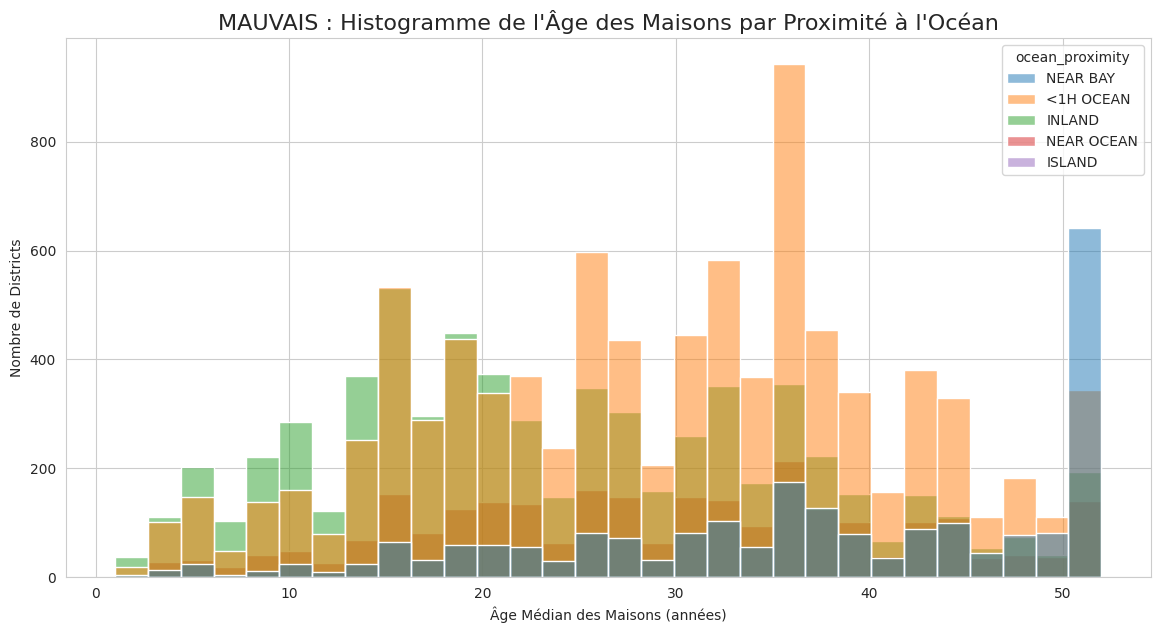


Analyse de cette mauvaise visualisation :
- Il est extrêmement difficile de comparer les distributions. Par exemple, on ne peut pas dire facilement si la distribution pour 'INLAND' est plus jeune ou plus vieille que celle pour 'NEAR BAY'.
- Les couleurs se chevauchent, créant un mélange confus.
- Cette visualisation ne répond pas efficacement à notre question.



In [7]:
# La mauvaise approche : un histogramme avec trop de groupes
plt.figure(figsize=(14, 7))
sns.histplot(
    data=housing_df,
    x='housing_median_age',
    hue='ocean_proximity',
    bins=30,
    multiple='layer' # 'layer' ou 'stack' rendent la comparaison difficile
)
plt.title('MAUVAIS : Histogramme de l\'Âge des Maisons par Proximité à l\'Océan', fontsize=16)
plt.xlabel('Âge Médian des Maisons (années)')
plt.ylabel('Nombre de Districts')
plt.show()

print("""
Analyse de cette mauvaise visualisation :
- Il est extrêmement difficile de comparer les distributions. Par exemple, on ne peut pas dire facilement si la distribution pour 'INLAND' est plus jeune ou plus vieille que celle pour 'NEAR BAY'.
- Les couleurs se chevauchent, créant un mélange confus.
- Cette visualisation ne répond pas efficacement à notre question.
""")

Les Bonnes Approches (Box Plot & Violin Plot) (Code)

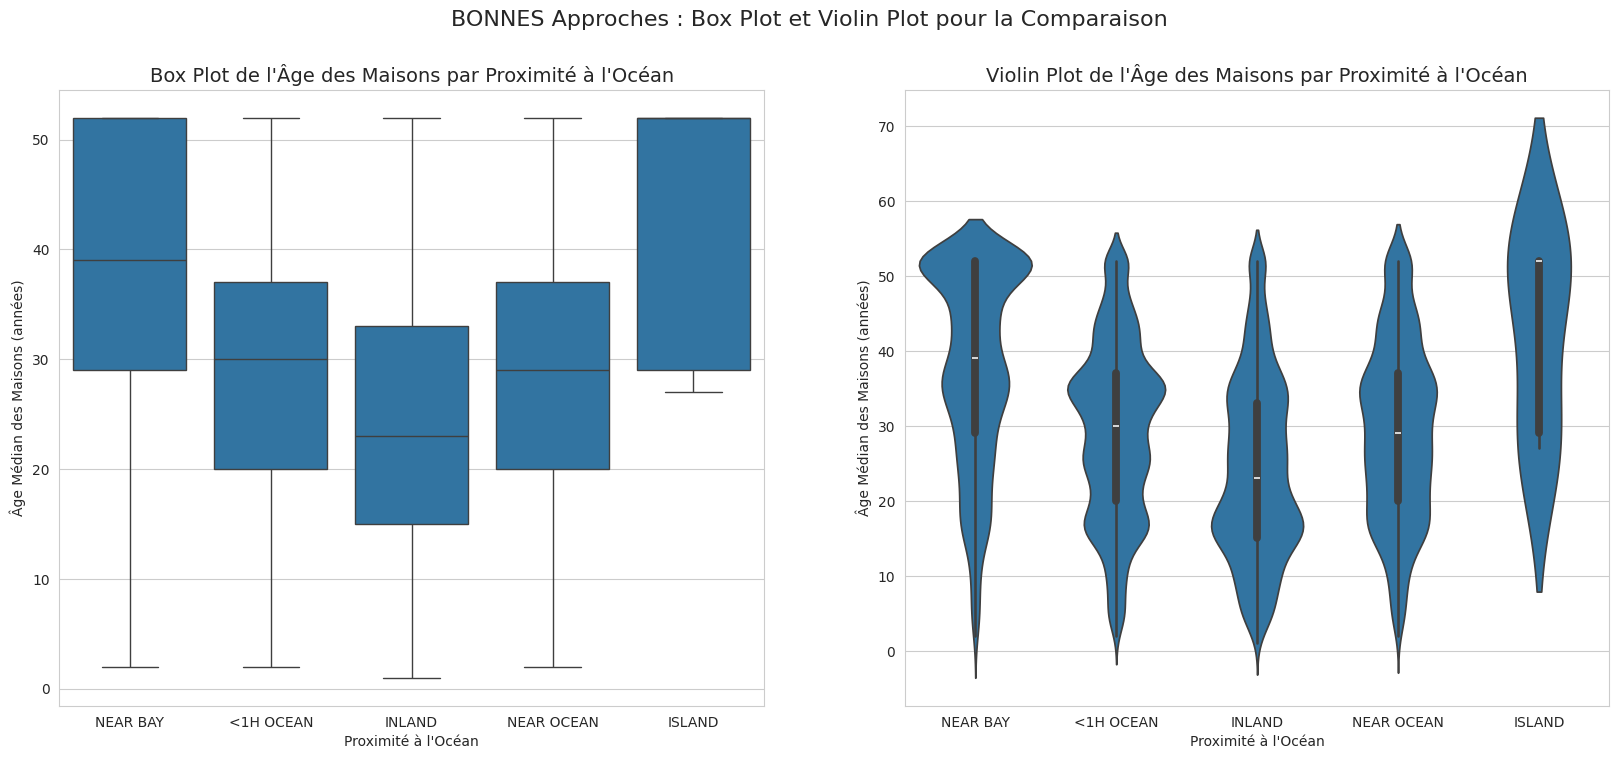


Analyse des visualisations appropriées :
- **Box Plot :** Il est maintenant trivial de comparer les groupes.
  - On voit immédiatement que les maisons 'INLAND' sont globalement plus jeunes (médiane plus basse).
  - Les maisons 'NEAR BAY' et 'NEAR OCEAN' semblent plus anciennes.
  - La boîte (IQR) nous donne la dispersion, et les moustères nous montrent l'étendue des valeurs.
- **Violin Plot :** C'est le meilleur des deux mondes.
  - Il combine la synthèse du box plot (la barre blanche au centre représente la médiane et l'IQR).
  - Il ajoute la forme de la distribution (la largeur du "violon"). On voit par exemple que la distribution pour 'INLAND' est plus concentrée, tandis que 'NEAR OCEAN' a une distribution plus plate et large.



In [8]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('BONNES Approches : Box Plot et Violin Plot pour la Comparaison', fontsize=16)

# Bonne approche 1 : Le Box Plot
sns.boxplot(
    data=housing_df,
    x='ocean_proximity',
    y='housing_median_age',
    ax=axes[0]
)
axes[0].set_title('Box Plot de l\'Âge des Maisons par Proximité à l\'Océan', fontsize=14)
axes[0].set_xlabel('Proximité à l\'Océan')
axes[0].set_ylabel('Âge Médian des Maisons (années)')

# Bonne approche 2 : Le Violin Plot (encore plus riche)
sns.violinplot(
    data=housing_df,
    x='ocean_proximity',
    y='housing_median_age',
    ax=axes[1]
)
axes[1].set_title('Violin Plot de l\'Âge des Maisons par Proximité à l\'Océan', fontsize=14)
axes[1].set_xlabel('Proximité à l\'Océan')
axes[1].set_ylabel('Âge Médian des Maisons (années)')

plt.show()

print("""
Analyse des visualisations appropriées :
- **Box Plot :** Il est maintenant trivial de comparer les groupes.
  - On voit immédiatement que les maisons 'INLAND' sont globalement plus jeunes (médiane plus basse).
  - Les maisons 'NEAR BAY' et 'NEAR OCEAN' semblent plus anciennes.
  - La boîte (IQR) nous donne la dispersion, et les moustères nous montrent l'étendue des valeurs.
- **Violin Plot :** C'est le meilleur des deux mondes.
  - Il combine la synthèse du box plot (la barre blanche au centre représente la médiane et l'IQR).
  - Il ajoute la forme de la distribution (la largeur du "violon"). On voit par exemple que la distribution pour 'INLAND' est plus concentrée, tandis que 'NEAR OCEAN' a une distribution plus plate et large.
""")

### Cas 2 : Visualiser des Données Catégorielles

**La Question :** Quel est le nombre de districts pour chaque catégorie de proximité à l'océan ?

**Pourquoi l'histogramme est un mauvais choix :**
Un histogramme est conçu pour des données continues, regroupées en intervalles (bins). Appliquer un histogramme à des données catégorielles n'a pas de sens. Le concept d'intervalle entre "INLAND" et "NEAR OCEAN" est inexistant. L'outil essaierait de créer des "bins" pour des étiquettes, ce qui est une erreur conceptuelle.

Tenter de faire un histogramme sur des données catégorielles est une erreur conceptuelle.
L'outil ne sait pas comment 'biner' des catégories comme 'A', 'B', 'C', 'D'.
Il n'y a pas d'ordre ou d'intervalle logique entre ces étiquettes.

Codes numériques arbitraires générés pour les catégories :
  categorie  code
0         A     0
1         B     1
3         C     2
7         D     3


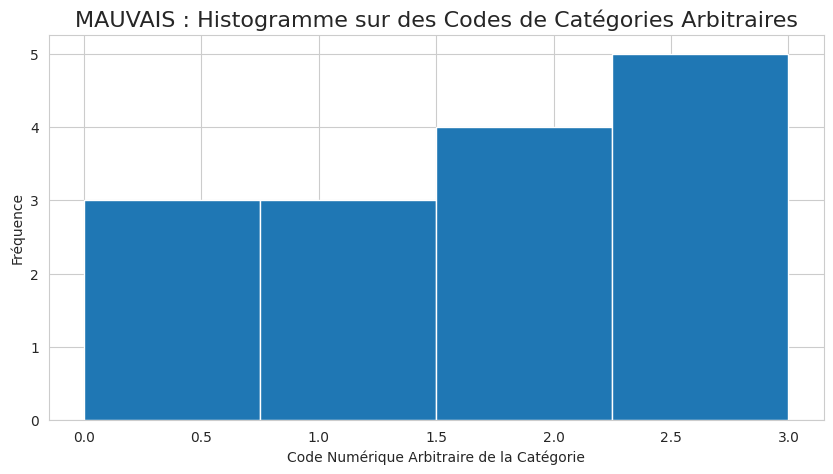


Analyse de cette mauvaise visualisation :
- L'axe des X est meaningless. Pourquoi la catégorie 'B' (code 1) serait-elle "avant" la catégorie 'C' (code 2) ?
- Cette visualisation suggère un ordre et une continuité qui n'existent pas.
- Elle ne répond pas à la question "Combien y a-t-il d'occurrences de chaque catégorie ?".



In [9]:
# Création d'un DataFrame simple pour l'exemple
categorical_data = pd.DataFrame({
    'categorie': ['A', 'B', 'A', 'C', 'B', 'B', 'A', 'D', 'C', 'C', 'C', 'D', 'D', 'D', 'D']
})

# La mauvaise approche : tenter un histogramme sur des catégories
# Note : Seaborn/Matplotlib sont assez intelligents pour ne pas le faire directement ou pour le transformer en countplot,
# mais l'intention est de montrer l'erreur conceptuelle.
# Si on force une interprétation numérique, c'est un désastre.
print("Tenter de faire un histogramme sur des données catégorielles est une erreur conceptuelle.")
print("L'outil ne sait pas comment 'biner' des catégories comme 'A', 'B', 'C', 'D'.")
print("Il n'y a pas d'ordre ou d'intervalle logique entre ces étiquettes.")

# Si on transforme les catégories en codes numériques juste pour l'exemple...
categorical_data['code'] = categorical_data['categorie'].astype('category').cat.codes
print("\nCodes numériques arbitraires générés pour les catégories :")
print(categorical_data.drop_duplicates().sort_values('code'))

plt.figure(figsize=(10, 5))
plt.hist(categorical_data['code'], bins=4)
plt.title("MAUVAIS : Histogramme sur des Codes de Catégories Arbitraires", fontsize=16)
plt.xlabel("Code Numérique Arbitraire de la Catégorie")
plt.ylabel("Fréquence")
plt.show()

print("""
Analyse de cette mauvaise visualisation :
- L'axe des X est meaningless. Pourquoi la catégorie 'B' (code 1) serait-elle "avant" la catégorie 'C' (code 2) ?
- Cette visualisation suggère un ordre et une continuité qui n'existent pas.
- Elle ne répond pas à la question "Combien y a-t-il d'occurrences de chaque catégorie ?".
""")

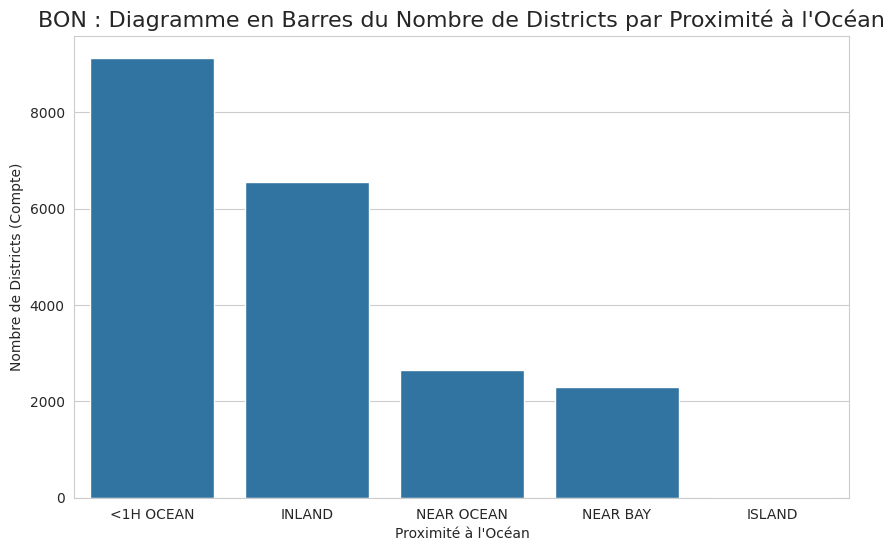


Analyse de la visualisation appropriée :
- Chaque barre représente une catégorie discrète et distincte.
- La hauteur de la barre correspond directement au décompte des occurrences.
- Il est immédiatement clair que '<1H OCEAN' est la catégorie la plus fréquente, suivie par 'INLAND'.
- C'est la manière la plus directe et la plus intuitive de comparer des quantités entre catégories.



In [10]:
# La bonne approche : un diagramme en barres (countplot)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=housing_df,
    x='ocean_proximity',
    order=housing_df['ocean_proximity'].value_counts().index # Trier par fréquence
)
plt.title('BON : Diagramme en Barres du Nombre de Districts par Proximité à l\'Océan', fontsize=16)
plt.xlabel('Proximité à l\'Océan')
plt.ylabel('Nombre de Districts (Compte)')
plt.show()

print("""
Analyse de la visualisation appropriée :
- Chaque barre représente une catégorie discrète et distincte.
- La hauteur de la barre correspond directement au décompte des occurrences.
- Il est immédiatement clair que '<1H OCEAN' est la catégorie la plus fréquente, suivie par 'INLAND'.
- C'est la manière la plus directe et la plus intuitive de comparer des quantités entre catégories.
""")

### Cas 3 : Visualiser la Relation entre Deux Variables Numériques

**La Question :** Existe-t-il une relation entre le revenu médian des ménages (`median_income`) et la valeur médiane des maisons (`median_house_value`) ?

**Pourquoi l'histogramme est un mauvais choix :**
Un histogramme est univarié. Il ne peut montrer qu'une seule variable à la fois. Tracer deux histogrammes séparés, un pour le revenu et un pour la valeur de la maison, nous donne des informations sur leurs distributions *individuelles*, mais **zéro information** sur leur relation. On ne saura jamais si un revenu élevé "correspond" à une maison de grande valeur.

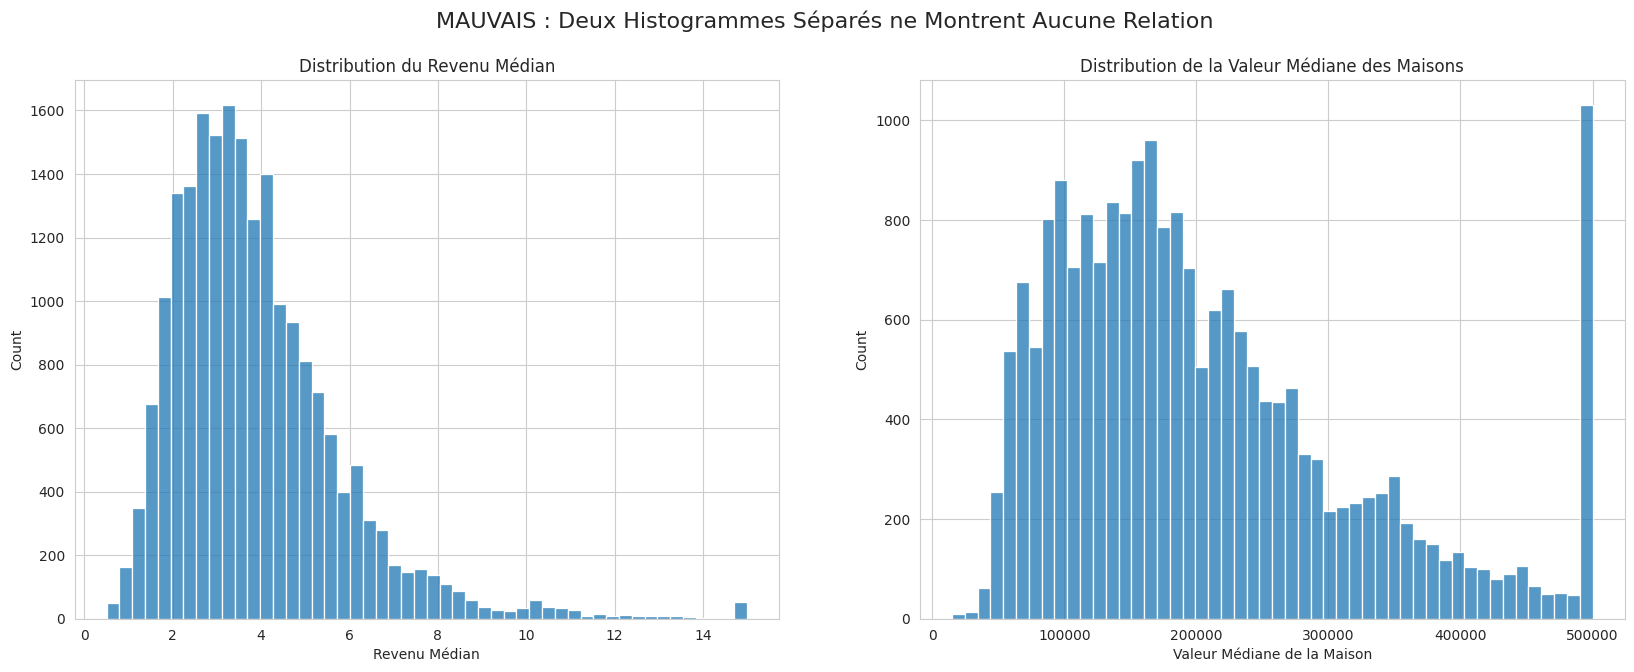


Analyse de cette mauvaise approche :
- Nous savons que le revenu est asymétrique à droite et que la valeur des maisons l'est aussi.
- Nous savons qu'il y a un pic de maisons à 500 000$.
- **MAIS** nous ne pouvons PAS répondre à la question : "Les ménages avec un revenu plus élevé vivent-ils dans des maisons plus chères ?".
- Ces deux graphiques ne sont pas connectés. Ils racontent deux histoires séparées.



In [11]:
# La mauvaise approche : deux histogrammes séparés
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle("MAUVAIS : Deux Histogrammes Séparés ne Montrent Aucune Relation", fontsize=16)

sns.histplot(housing_df['median_income'], bins=50, ax=axes[0])
axes[0].set_title('Distribution du Revenu Médian')
axes[0].set_xlabel('Revenu Médian')

sns.histplot(housing_df['median_house_value'], bins=50, ax=axes[1])
axes[1].set_title('Distribution de la Valeur Médiane des Maisons')
axes[1].set_xlabel('Valeur Médiane de la Maison')

plt.show()

print("""
Analyse de cette mauvaise approche :
- Nous savons que le revenu est asymétrique à droite et que la valeur des maisons l'est aussi.
- Nous savons qu'il y a un pic de maisons à 500 000$.
- **MAIS** nous ne pouvons PAS répondre à la question : "Les ménages avec un revenu plus élevé vivent-ils dans des maisons plus chères ?".
- Ces deux graphiques ne sont pas connectés. Ils racontent deux histoires séparées.
""")

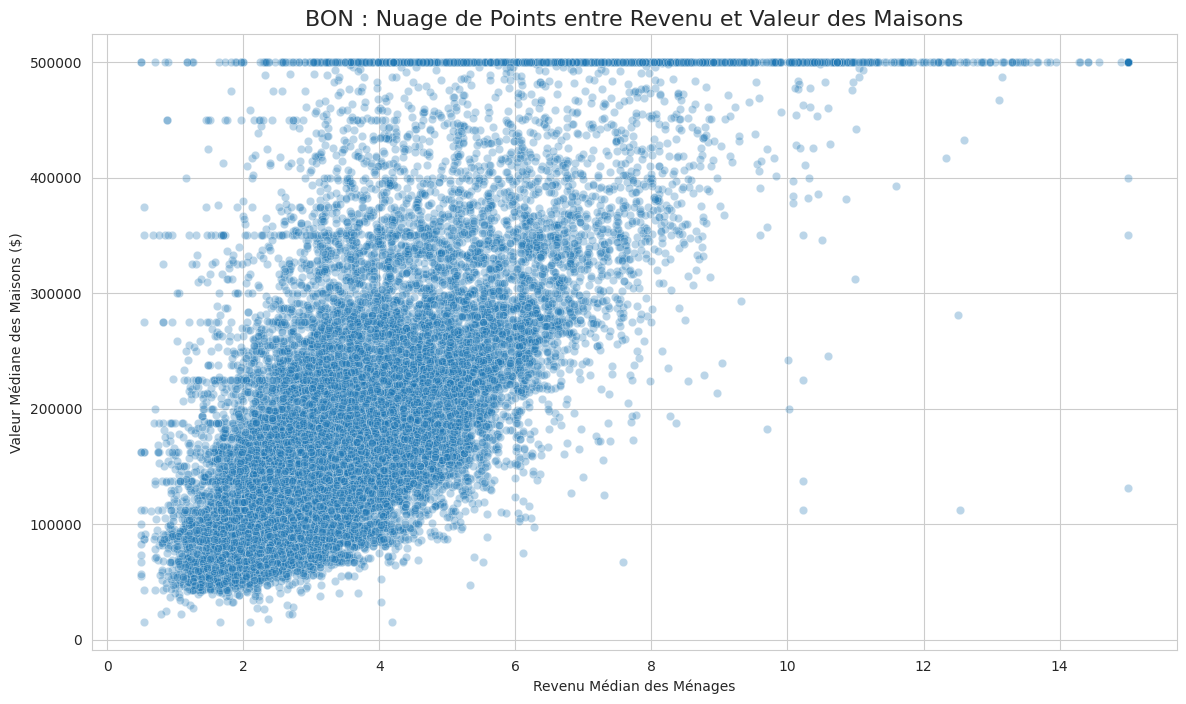


Analyse de la visualisation appropriée :
- La réponse à notre question est maintenant ÉVIDENTE.
- Il existe une forte corrélation positive : lorsque le revenu médian augmente, la valeur médiane des maisons augmente également.
- On voit la ligne horizontale à 500 000$, confirmant que ce plafonnement affecte toutes les tranches de revenu.
- On peut même observer des "lignes" horizontales à d'autres niveaux (ex: ~350 000$, ~450 000$), ce qui pourrait indiquer des pratiques de tarification ou des effets de marché locaux.
- Le nuage de points est l'outil indispensable pour explorer la relation entre deux variables numériques.



In [12]:
# La bonne approche : un nuage de points (scatter plot)
plt.figure(figsize=(14, 8))
# On utilise un alpha pour gérer le sur-plotting (trop de points superposés)
sns.scatterplot(
    data=housing_df,
    x='median_income',
    y='median_house_value',
    alpha=0.3
)
plt.title('BON : Nuage de Points entre Revenu et Valeur des Maisons', fontsize=16)
plt.xlabel('Revenu Médian des Ménages')
plt.ylabel('Valeur Médiane des Maisons ($)')
plt.show()

print("""
Analyse de la visualisation appropriée :
- La réponse à notre question est maintenant ÉVIDENTE.
- Il existe une forte corrélation positive : lorsque le revenu médian augmente, la valeur médiane des maisons augmente également.
- On voit la ligne horizontale à 500 000$, confirmant que ce plafonnement affecte toutes les tranches de revenu.
- On peut même observer des "lignes" horizontales à d'autres niveaux (ex: ~350 000$, ~450 000$), ce qui pourrait indiquer des pratiques de tarification ou des effets de marché locaux.
- Le nuage de points est l'outil indispensable pour explorer la relation entre deux variables numériques.
""")

## Conclusion : La Boîte à Outils du Data Analyst

Cet exposé démontre une règle d'or en visualisation de données : **le choix du graphique est dicté par la question que vous posez.**

- **Question : "Quelle est la forme de la distribution de cette variable numérique ?"**
  - **Outil :** Histogramme.

- **Question : "Comment les distributions de cette variable numérique se comparent-elles entre plusieurs groupes ?"**
  - **Outils :** Box Plot (pour la synthèse), Violin Plot (pour la forme + synthèse).

- **Question : "Comment les quantités se comparent-elles entre différentes catégories ?"**
  - **Outil :** Diagramme en barres (Bar Chart / Countplot).

- **Question : "Y a-t-il une relation ou une corrélation entre ces deux variables numériques ?"**
  - **Outil :** Nuage de points (Scatter Plot).

Maîtriser ces distinctions est ce qui élève une simple présentation de données à une véritable analyse perspicace. L'histogramme est un outil puissant, mais ce n'est qu'un outil parmi d'autres dans la boîte à outils essentielle du data analyst.